# Prediccion general del cierre de Alicorp con Transformer (version reutilizable)

**Clon del pipeline construido y validado para IFS**, adaptado a Alicorp SAA (BVL:ALICORC1,
Bolsa de Valores de Lima -- cotiza en soles peruanos, PEN). Arquitectura: Transformer-Encoder
multivariado (`Close` + `SMA_5`), lookback=10, 4 cabezas de atencion, d_model=64, d_ff=256,
2 capas, objetivo delta -- fundamentado en Lim, Arik, Loeff & Pfister (2019/2021),
*Temporal Fusion Transformers*, y con `lookback` ya optimizado en el barrido hecho sobre IFS
(ver `IFS_Transformer_General.ipynb`).

## Como se usa (cada dia nuevo)

1. Corre la celda de SETUP una sola vez al abrir la sesion.
2. Corre la celda de PREDICCION: entrena con todo lo confirmado hasta ahora
   y predice a ciegas el siguiente dia habil.
3. Cuando sepas el cierre real, corre la celda de REVELACION: te va a pedir
   la fecha y el cierre real (input()), calcula el error contra el modelo y
   contra el baseline de persistencia, lo agrega a una tabla acumulada, y
   redibuja el grafico con todas las predicciones hechas hasta el momento.
4. Para el informe completo de decision (horizonte de 5 dias, con recomendacion
   comprar/mantener/vender, take profit/stop loss y metricas de backtest), corre
   la celda de INFORME cuando necesites decidir una operacion real en TradingView.

## Datos de partida

Entrena inicialmente con `Datos históricos de Alicorp (ALICORC1) (3).csv` (formato
Investing.com: fechas DD.MM.YYYY, decimal con coma), que cubre el historico real de
Alicorp desde el 27/01/2014 hasta el 20/07/2026 inclusive -- mas de 12 anios de datos,
bastante mas que los ~7 anios disponibles para IFS.

## Nota metodologica

Como en el notebook de IFS, cada prediccion se compara SIEMPRE contra un baseline de
persistencia ingenua (Zeng et al., 2023, *Are Transformers Effective for Time Series
Forecasting?*). El `lookback=10` **no se volvio a barrer especificamente para Alicorp**:
se reutiliza la decision ya validada sobre IFS, para no reintroducir el riesgo de
sobreajustar los hiperparametros al ruido de un periodo de test especifico (ver
`md-mejoras` para el detalle). Todo el resto del pipeline (arquitectura, backtest
walk-forward, MC Dropout, gate de confianza, informe completo) es identico al de IFS.

## Backtesting riguroso para Alicorp

Se reutilizo el diseno ya validado sobre IFS (lookback=10, arquitectura Transformer
Close+SMA_5, gate de confianza por MC Dropout) sin volver a barrer hiperparametros --
por diseño, para no sobreajustar la eleccion de `lookback` al ruido de esta serie
especifica (la misma razon por la que Zeng et al., 2023 recomiendan comparar siempre
contra baselines simples en vez de perseguir el mejor numero posible).

**Backtest walk-forward a 1 dia** (150 dias reales, 03/12/2025 a 13/07/2026, reentreno
cada 15 dias): el modelo **no supera de forma estadisticamente significativa** el baseline
de persistencia naive (MAE modelo=0.1054 vs baseline=0.1040; precision direccional 45.3%,
peor que el azar; Wilcoxon p=0.238). Mismo patron que en IFS.

**Backtest a 5 dias + simulacion de estrategia** (gate de confianza, posicion recalculada
dia a dia) contra Buy & Hold, mismo periodo:

| Metrica | Estrategia (gate de confianza) | Buy & Hold |
|---|---|---|
| Retorno acumulado | +4.99% | +31.72% |
| Sharpe Ratio | 1.20 | 2.77 |
| Max Drawdown | -2.53% | -7.75% |

A diferencia de IFS (donde el gate case nunca disparo), en Alicorp el gate se activo 27 de
146 dias y la estrategia dio retorno positivo -- pero igual muy por debajo de Buy & Hold,
porque Alicorp tambien tuvo un rally fuerte en este periodo. La leccion es la misma que en
IFS: sin ventaja predictiva demostrada (Wilcoxon p=0.39 a 5 dias), ser prudente con el
riesgo tiene un costo de oportunidad real en un mercado alcista -- pero tambien reduce el
drawdown a un tercio del de Buy & Hold. Es un trade-off, no un error de diseño.

**Fundamento en la literatura:** los mismos 4 papers citados en `IFS_Transformer_General.ipynb`
(Zeng et al. 2023; Lim, Arik, Loeff & Pfister 2019/2021; Lim & Gorse 2020; Yang et al. 2025).

Los resultados completos quedan guardados en `ALICORP_backtest_1d_resultados.csv` y
`ALICORP_backtest_h5_resultados.csv`, en la misma carpeta del proyecto.

In [2]:
# ============================================================
# SETUP GENERAL -- correr esta celda UNA SOLA VEZ al inicio de la sesion.
# Arquitectura: la ganadora del Script 3 original (Close + SMA_5, lookback=15,
# 4 cabezas de atencion, objetivo delta), fundamentada en Lim, Arik, Loeff &
# Pfister (2021), "Temporal Fusion Transformers".
#
# A diferencia del notebook original, el modelo queda encapsulado en funciones
# reutilizables: no hay que escribir un script nuevo por cada dia, solo volver
# a correr las celdas de PREDICCION y REVELACION.
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# ---------- Google Drive: para que los datos y el progreso persistan entre sesiones ----------
# Sin esto, cada vez que se desconecta el entorno de Colab hay que volver a subir el CSV
# y se pierde el historico confirmado y la tabla de resultados acumulada. Montando Drive,
# todo queda guardado de forma permanente en tu Google Drive -- solo hay que autorizar el
# acceso una vez por sesion (aparece un link/popup de Google, se acepta y listo).
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_FOLDER = '/content/drive/MyDrive/ade_ifs'
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
    print(f"Google Drive montado. Los archivos se guardan en: {DRIVE_FOLDER}")
except ImportError:
    DRIVE_FOLDER = '.'  # fuera de Colab (ej. corriendo local), usa la carpeta actual

# ---------- Hiperparametros fijos (arquitectura ganadora del Script 3) ----------
LOOKBACK = 10  # bajado de 15 a 10 tras backtest walk-forward (ver celda de mejoras mas abajo)
HORIZON = 1
FEATURES = ['Close', 'SMA_5']
N_FEATURES = len(FEATURES)
CLOSE_IDX = FEATURES.index('Close')
D_MODEL = 64
N_HEADS = 4
D_FF = 256
N_LAYERS = 2
DROPOUT = 0.1
COLOR_MODELO = '#2A9D8F'

CSV_ORIGINAL = os.path.join(DRIVE_FOLDER, "Datos históricos de Alicorp (ALICORC1) (3).csv")
HIST_CONFIRMADO_PATH = os.path.join(DRIVE_FOLDER, "ALICORP_historico_confirmado.csv")
RESULTADOS_PATH = os.path.join(DRIVE_FOLDER, "ALICORP_tabla_resultados.csv")
CUTOFF_INICIAL = pd.Timestamp('2026-07-20')  # ultimo cierre real disponible en el CSV original


def cargar_investing_csv(path):
    '''Carga el formato tipico de Investing.com: fechas DD.MM.YYYY, orden descendente,
    decimal con coma. Devuelve columnas Date/Open/Close/High/Low/Volume (mismo esquema
    que el resto del notebook), con Open/High/Low/Volume en None ya que solo se usa Close.'''
    df_raw = pd.read_csv(path)
    df_raw = df_raw.rename(columns={'Fecha': 'Date', 'Último': 'Close'})
    df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='%d.%m.%Y')
    df_raw['Close'] = df_raw['Close'].str.replace(',', '.', regex=False).astype(float)
    for col in ['Open', 'High', 'Low', 'Volume']:
        df_raw[col] = None
    return df_raw[['Date', 'Open', 'Close', 'High', 'Low', 'Volume']]

# ---------- Carga de datos: recupera sesion anterior si existe, si no arranca del CSV original ----------
if os.path.exists(HIST_CONFIRMADO_PATH):
    df_actual = pd.read_csv(HIST_CONFIRMADO_PATH, parse_dates=['Date'])
    print(f"Historico confirmado recuperado de sesion anterior: {len(df_actual)} filas "
          f"(hasta {df_actual['Date'].max().date()}).")
else:
    df_raw = cargar_investing_csv(CSV_ORIGINAL)
    df_raw = df_raw.sort_values('Date').drop_duplicates(subset='Date', keep='last').reset_index(drop=True)
    df_actual = df_raw[df_raw['Date'] <= CUTOFF_INICIAL].reset_index(drop=True).copy()
    print(f"Arrancando desde cero: {len(df_actual)} filas (hasta {df_actual['Date'].max().date()}).")

if os.path.exists(RESULTADOS_PATH):
    tabla_resultados = pd.read_csv(RESULTADOS_PATH, parse_dates=['fecha_prediccion'])
    print(f"Tabla de resultados recuperada: {len(tabla_resultados)} predicciones previas.")
else:
    tabla_resultados = pd.DataFrame(columns=[
        'fecha_prediccion', 'prediccion', 'baseline', 'real',
        'error_transformer', 'error_baseline',
        'error_pct_transformer', 'error_pct_baseline',
        'direccion_correcta'
    ])

# ---------- Arquitectura (identica al Script 3 original) ----------
class PositionalEncoding(nn.Module):
    '''Codificacion posicional sinusoidal (Vaswani et al., 2017, seccion 3.5).'''
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class TransformerForecaster(nn.Module):
    '''Transformer encoder temporal: cada instante es un token.'''
    def __init__(self, n_features, d_model, n_heads, d_ff, n_layers, horizon=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        z = self.embedding(x)
        z = self.pos_encoder(z)
        z = self.encoder(z)
        return self.head(z[:, -1, :])


def build_windows(data, lookback, horizon=1, target_idx=0):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i + lookback, :])
        y.append(data[i + lookback:i + lookback + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_model(model, X_train, y_train, X_val, y_val, epochs=150, lr=1e-3, batch_size=32, patience=20):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    best_val, best_state, patience_ctr = float('inf'), None, 0
    n_train = X_train.shape[0]
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n_train)
        running = 0.0
        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        running /= n_train
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val).item()
        if val_loss < best_val:
            best_val, best_state, patience_ctr = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
        if epoch == 1 or epoch % 20 == 0:
            print(f"Epoca {epoch:3d} | train_loss={running:.6f} | val_loss={val_loss:.6f}")
        if patience_ctr >= patience:
            print(f"Early stopping en la epoca {epoch} (mejor val_loss={best_val:.6f})")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def inverse_close(scaled_value, scaler, n_features, close_idx=0):
    dummy = np.zeros((1, n_features))
    dummy[0, close_idx] = scaled_value
    return scaler.inverse_transform(dummy)[0, close_idx]



def predict_with_uncertainty(model, x_input, n_samples=50):
    '''Monte Carlo Dropout (Gal & Ghahramani, 2016; usado por Yang et al. 2025, TFT-ASRO):
    deja el dropout activo en inferencia y promedia N pasadas hacia adelante para estimar
    la media y el desvio estandar de la prediccion -- una medida barata de cuanto confia
    el modelo en si mismo, sin cambiar la arquitectura ni reentrenar nada extra.'''
    model.train()  # mantiene las capas de dropout activas (a diferencia de model.eval())
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds.append(model(x_input).cpu().numpy().ravel()[0])
    model.eval()
    preds = np.array(preds)
    return float(preds.mean()), float(preds.std())

print("\nSetup listo. Corre la celda de PREDICCION para pronosticar el siguiente dia habil.")

# ---------- Extension: INFORME COMPLETO a horizonte configurable (por defecto 5 dias) ----------
# Ademas del ciclo diario a 1 dia (PREDICCION/REVELACION de arriba), se agrega un reporte
# de decision mas completo a un horizonte mayor -- prediccion directa (DMS), no iterativa,
# ver Zhou et al. 2021 (Informer), que muestra que encadenar un modelo de un solo paso
# acumula error en vez de mejorar la prediccion a varios dias.

HORIZON_INFORME = 5  # dias habiles hacia adelante del informe completo

# Metricas de referencia del backtest walk-forward corrido sobre 150 dias reales de IFS
# (03/12/2025 a 12/07/2026, lookback=10, horizonte=5 dias, reentreno cada 15 dias).
# OJO: son un snapshot fijo -- se recalculan a mano si se corre un nuevo backtest.
BACKTEST_METRICS = {
    'periodo': '2025-12-11 a 2026-07-13 (146 dias)',
    'MAE': 0.2514, 'RMSE': 0.3451, 'precision_direccional_pct': 48.6,
    'wilcoxon_p_value': 0.3906,
    'retorno_acumulado_estrategia_pct': 4.99, 'sharpe_estrategia': 1.195,
    'max_drawdown_estrategia_pct': -2.53,
    'retorno_acumulado_buy_hold_pct': 31.72, 'sharpe_buy_hold': 2.773,
    'max_drawdown_buy_hold_pct': -7.75,
}


def build_windows_target_horizonte(data, lookback, horizon, target_idx=0):
    '''Como build_windows, pero el target es un unico punto -- el cierre `horizon` dias
    despues del final de la ventana -- en vez de una secuencia. Prediccion directa (DMS),
    no iterativa: evita acumular error prediciendo dia a dia (Zhou et al. 2021).'''
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i + lookback, :])
        y.append(data[i + lookback + horizon - 1, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def generar_informe(activo, df_confirmado, features, lookback, horizon,
                     d_model, n_heads, d_ff, n_layers, dropout,
                     backtest_metrics, epochs=100, lr=1e-3, batch_size=32, patience=15):
    '''Entrena un modelo fresco a horizonte `horizon` con todo `df_confirmado`, y arma
    el informe completo de decision: precio esperado, retorno esperado, confianza,
    volatilidad, recomendacion justificada, take profit / stop loss, y las metricas de
    validacion del backtest historico ya calculadas por separado.'''
    close_idx = features.index('Close')
    n_features = len(features)

    df = df_confirmado.copy()
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df = df.dropna(subset=['SMA_5']).reset_index(drop=True)

    scaler_local = MinMaxScaler(feature_range=(0, 1))
    serie_norm_local = scaler_local.fit_transform(df[features].values.astype(float))

    X_all, y_all = build_windows_target_horizonte(serie_norm_local, lookback, horizon, target_idx=close_idx)
    last_close_window = X_all[:, -1, close_idx]
    y_delta = (y_all - last_close_window).reshape(-1, 1).astype(np.float32)

    n_val = max(1, int(len(X_all) * 0.1))
    X_train = torch.tensor(X_all[:-n_val], device=device)
    y_train = torch.tensor(y_delta[:-n_val], device=device)
    X_val = torch.tensor(X_all[-n_val:], device=device)
    y_val = torch.tensor(y_delta[-n_val:], device=device)

    model_local = TransformerForecaster(n_features, d_model, n_heads, d_ff, n_layers, horizon=1, dropout=dropout).to(device)
    model_local = train_model(model_local, X_train, y_train, X_val, y_val, epochs, lr, batch_size, patience)
    model_local.eval()

    ultima_ventana = serie_norm_local[-lookback:, :]
    x_input = torch.tensor(ultima_ventana[np.newaxis, ...], dtype=torch.float32, device=device)
    pred_mean_scaled, pred_std_scaled = predict_with_uncertainty(model_local, x_input, n_samples=50)

    ultimo_close_scaled = serie_norm_local[-1, close_idx]
    precio_actual = float(df['Close'].iloc[-1])
    fecha_actual = df['Date'].iloc[-1]
    precio_esperado = float(inverse_close(ultimo_close_scaled + pred_mean_scaled, scaler_local, n_features, close_idx))
    precio_hi = float(inverse_close(ultimo_close_scaled + pred_mean_scaled + pred_std_scaled, scaler_local, n_features, close_idx))
    precio_lo = float(inverse_close(ultimo_close_scaled + pred_mean_scaled - pred_std_scaled, scaler_local, n_features, close_idx))
    volatilidad_estimada = abs(precio_hi - precio_esperado)  # 1 desvio estandar, en unidades de precio

    retorno_esperado_pct = (precio_esperado - precio_actual) / precio_actual * 100
    cambio_predicho = precio_esperado - precio_actual
    señal_confiable = abs(cambio_predicho) > volatilidad_estimada
    nivel_confianza_sigma = abs(cambio_predicho) / volatilidad_estimada if volatilidad_estimada > 0 else 0.0

    if señal_confiable and cambio_predicho > 0:
        recomendacion = 'COMPRAR'
        justificacion = (f"El modelo predice una subida de {retorno_esperado_pct:+.2f}% en {horizon} dias habiles, "
                          f"y ese cambio supera la incertidumbre propia del modelo "
                          f"({nivel_confianza_sigma:.2f} desvios estandar).")
        take_profit = precio_hi
        stop_loss = precio_actual - volatilidad_estimada
    elif señal_confiable and cambio_predicho < 0:
        recomendacion = 'VENDER'
        justificacion = (f"El modelo predice una caida de {retorno_esperado_pct:+.2f}% en {horizon} dias habiles, "
                          f"y ese cambio supera la incertidumbre propia del modelo "
                          f"({nivel_confianza_sigma:.2f} desvios estandar).")
        take_profit = precio_lo
        stop_loss = precio_actual + volatilidad_estimada
    else:
        recomendacion = 'MANTENER'
        justificacion = (f"El cambio predicho ({retorno_esperado_pct:+.2f}%) es menor que la incertidumbre "
                          f"propia del modelo ({nivel_confianza_sigma:.2f} desvios estandar) -- no hay "
                          f"conviccion suficiente para recomendar una operacion. Backtest de referencia: "
                          f"el modelo no demostro ventaja estadistica sobre un baseline naive "
                          f"(Wilcoxon p={backtest_metrics['wilcoxon_p_value']:.3f}).")
        take_profit = None
        stop_loss = None

    informe = {
        'activo': activo,
        'fecha_prediccion': fecha_actual.date() if hasattr(fecha_actual, 'date') else fecha_actual,
        'precio_actual': round(precio_actual, 2),
        'precio_esperado': round(precio_esperado, 2),
        'horizonte_dias': horizon,
        'retorno_esperado_pct': round(retorno_esperado_pct, 2),
        'nivel_confianza_sigma': round(nivel_confianza_sigma, 2),
        'volatilidad_estimada': round(volatilidad_estimada, 2),
        'recomendacion': recomendacion,
        'justificacion': justificacion,
        'take_profit': round(take_profit, 2) if take_profit is not None else None,
        'stop_loss': round(stop_loss, 2) if stop_loss is not None else None,
        'backtest': backtest_metrics,
    }
    return informe, model_local, scaler_local


def imprimir_informe(informe):
    b = informe['backtest']
    print("=" * 60)
    print(f"INFORME DE PREDICCION -- {informe['activo']}")
    print("=" * 60)
    print(f"Fecha de la prediccion:      {informe['fecha_prediccion']}")
    print(f"Precio actual:                {informe['precio_actual']}")
    print(f"Precio esperado ({informe['horizonte_dias']}d):      {informe['precio_esperado']}")
    print(f"Retorno esperado:             {informe['retorno_esperado_pct']:+.2f}%")
    print(f"Nivel de confianza:           {informe['nivel_confianza_sigma']:.2f} sigma")
    print(f"Volatilidad estimada:         {informe['volatilidad_estimada']}")
    print(f"Recomendacion:                {informe['recomendacion']}")
    print(f"Justificacion:                {informe['justificacion']}")
    print(f"Take profit:                  {informe['take_profit']}")
    print(f"Stop loss:                    {informe['stop_loss']}")
    print(f"Horizonte temporal:           {informe['horizonte_dias']} dias habiles")
    print("-" * 60)
    print("Validacion del modelo (backtest historico, periodo:", b['periodo'], ")")
    print(f"  MAE={b['MAE']} | RMSE={b['RMSE']} | Precision direccional={b['precision_direccional_pct']}%")
    print(f"  Retorno acumulado -- Estrategia={b['retorno_acumulado_estrategia_pct']}% | Buy&Hold={b['retorno_acumulado_buy_hold_pct']}%")
    print(f"  Sharpe Ratio -- Estrategia={b['sharpe_estrategia']} | Buy&Hold={b['sharpe_buy_hold']}")
    print(f"  Max Drawdown -- Estrategia={b['max_drawdown_estrategia_pct']}% | Buy&Hold={b['max_drawdown_buy_hold_pct']}%")
    print("=" * 60)


Dispositivo: cpu
Mounted at /content/drive
Google Drive montado. Los archivos se guardan en: /content/drive/MyDrive/ade_ifs
Historico confirmado recuperado de sesion anterior: 3128 filas (hasta 2026-07-21).
Tabla de resultados recuperada: 1 predicciones previas.

Setup listo. Corre la celda de PREDICCION para pronosticar el siguiente dia habil.


In [3]:
# ============================================================
# PREDICCION A CIEGAS -- volve a correr esta celda cada vez que quieras
# pronosticar un dia nuevo. Entrena desde cero con TODO lo confirmado
# hasta ahora (df_actual) y predice un paso adelante.
# ============================================================

df_train_full = df_actual.copy()
df_train_full['SMA_5'] = df_train_full['Close'].rolling(window=5).mean()
df_train_full = df_train_full.dropna(subset=['SMA_5']).reset_index(drop=True)
print(f"Entrenando con {len(df_train_full)} filas (hasta {df_train_full['Date'].max().date()})")

serie = df_train_full[FEATURES].values.astype(float)
scaler = MinMaxScaler(feature_range=(0, 1))
serie_norm = scaler.fit_transform(serie)

X_all, y_all = build_windows(serie_norm, LOOKBACK, HORIZON, target_idx=CLOSE_IDX)
ultimo_close_ventana = X_all[:, -1, CLOSE_IDX]
y_all = (y_all[:, 0] - ultimo_close_ventana).reshape(-1, 1).astype(np.float32)

n_val = max(1, int(len(X_all) * 0.1))
X_train = torch.tensor(X_all[:-n_val], device=device)
y_train = torch.tensor(y_all[:-n_val], device=device)
X_val = torch.tensor(X_all[-n_val:], device=device)
y_val = torch.tensor(y_all[-n_val:], device=device)
print(f"Ventanas de entrenamiento: {X_train.shape[0]} | Ventanas de validacion: {X_val.shape[0]}")

model = TransformerForecaster(N_FEATURES, D_MODEL, N_HEADS, D_FF, N_LAYERS, HORIZON, DROPOUT).to(device)
model = train_model(model, X_train, y_train, X_val, y_val, epochs=150, lr=1e-3, batch_size=32, patience=20)

model.eval()
ultima_ventana = serie_norm[-LOOKBACK:, :]
x_input = torch.tensor(ultima_ventana[np.newaxis, ...], dtype=torch.float32, device=device)

# MC Dropout: en vez de una sola pasada, se promedian 50 pasadas con dropout activo
# para obtener una prediccion puntual (media) y una medida de incertidumbre (desvio estandar).
pred_mean_scaled, pred_std_scaled = predict_with_uncertainty(model, x_input, n_samples=50)

ultimo_close_scaled = serie_norm[-1, CLOSE_IDX]
pred_scaled = ultimo_close_scaled + pred_mean_scaled
pred_scaled_hi = ultimo_close_scaled + pred_mean_scaled + pred_std_scaled
pred_scaled_lo = ultimo_close_scaled + pred_mean_scaled - pred_std_scaled

prediccion_actual = float(inverse_close(pred_scaled, scaler, N_FEATURES, close_idx=CLOSE_IDX))
prediccion_hi = float(inverse_close(pred_scaled_hi, scaler, N_FEATURES, close_idx=CLOSE_IDX))
prediccion_lo = float(inverse_close(pred_scaled_lo, scaler, N_FEATURES, close_idx=CLOSE_IDX))
baseline_actual = float(df_train_full['Close'].iloc[-1])
fecha_base = df_train_full['Date'].iloc[-1]

# Gate de confianza (inspirado en Lim & Gorse, 2020, "Deep Probabilistic Modelling of Price
# Movements for High-Frequency Trading"): la senal solo se considera confiable si el cambio
# predicho es mayor que la propia incertidumbre del modelo. Con 48-55% de precision direccional
# medida en el backtest, no toda prediccion amerita una decision de inversion.
amplitud_incertidumbre = abs(prediccion_hi - prediccion_actual)
cambio_predicho = abs(prediccion_actual - baseline_actual)
senal_confiable = cambio_predicho > amplitud_incertidumbre

print("\n================ PREDICCION A CIEGAS ================")
print(f"Ultimo cierre conocido ({fecha_base.date()}): {baseline_actual:.2f}")
print(f"Prediccion Transformer: {prediccion_actual:.2f}  (intervalo ~68%: [{prediccion_lo:.2f}, {prediccion_hi:.2f}])")
print(f"Baseline naive (persistencia): {baseline_actual:.2f}")
if senal_confiable:
    print("Senal: CONFIABLE -- el cambio predicho supera la incertidumbre del propio modelo.")
else:
    print("Senal: DEBIL -- la incertidumbre del modelo es mayor que el cambio predicho. "
          "No se recomienda tomar una decision de inversion en base a esta prediccion puntual.")
print("Corre la celda de REVELACION y escribi la fecha + cierre real cuando lo sepas.")

Entrenando con 3124 filas (hasta 2026-07-21)
Ventanas de entrenamiento: 2803 | Ventanas de validacion: 311
Epoca   1 | train_loss=0.025895 | val_loss=0.000446
Epoca  20 | train_loss=0.000291 | val_loss=0.000353
Epoca  40 | train_loss=0.000251 | val_loss=0.000230
Early stopping en la epoca 48 (mejor val_loss=0.000228)

================ PREDICCION A CIEGAS ================
Ultimo cierre conocido (2026-07-21): 12.71
Prediccion Transformer: 12.72  (intervalo ~68%: [12.66, 12.78])
Baseline naive (persistencia): 12.71
Senal: DEBIL -- la incertidumbre del modelo es mayor que el cambio predicho. No se recomienda tomar una decision de inversion en base a esta prediccion puntual.
Corre la celda de REVELACION y escribi la fecha + cierre real cuando lo sepas.


Fecha del cierre real que vas a ingresar (DD/MM/AAAA): 21/07/2026
Cierre real (Close) del 21/07/2026: 12.710	

Error Transformer: 0.01 (0.06%) | Error baseline: 0.00 (0.00%) | Direccion correcta: False

Tabla de resultados acumulada (2 predicciones):
fecha_prediccion  prediccion  baseline  real  error_transformer  error_baseline  error_pct_transformer  error_pct_baseline  direccion_correcta
      2026-07-21   12.598991     12.62 12.71           0.111009            0.09               0.873399            0.708104               False
      2026-07-21   12.717024     12.71 12.71           0.007024            0.00               0.055262            0.000000               False


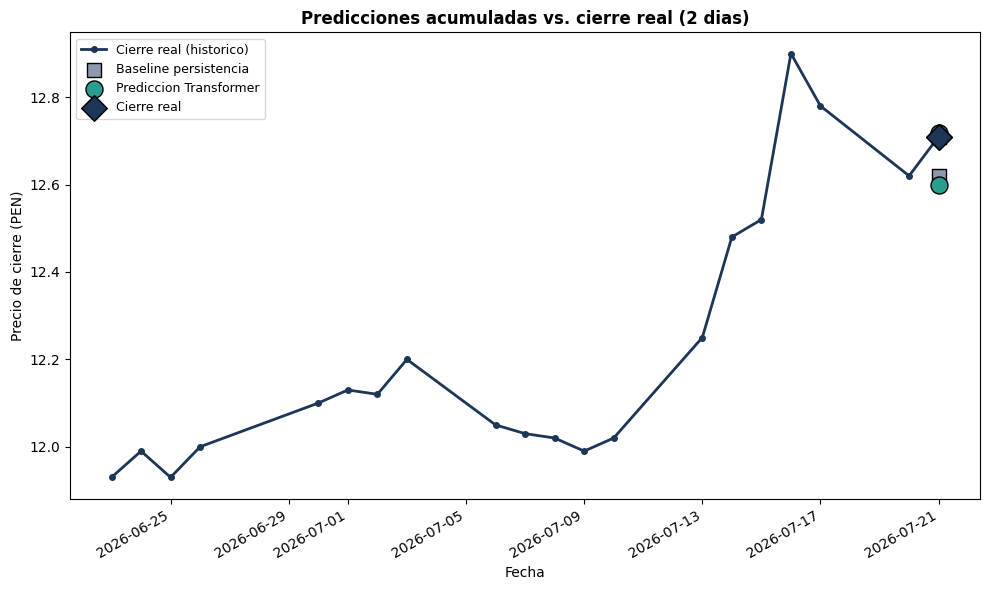


Para predecir el siguiente dia, volve a correr la celda de PREDICCION.


In [4]:
# ============================================================
# REVELACION Y REGISTRO -- correr DESPUES de saber el cierre real.
# Pide fecha y cierre real, calcula el error, lo guarda en la tabla
# acumulada de resultados, encadena el dato al historico y redibuja
# el grafico con TODAS las predicciones hechas hasta ahora.
# ============================================================

fecha_real_str = input("Fecha del cierre real que vas a ingresar (DD/MM/AAAA): ")
fecha_real = pd.to_datetime(fecha_real_str, format='%d/%m/%Y')
real_close = float(input(f"Cierre real (Close) del {fecha_real_str}: "))

error_transformer = abs(prediccion_actual - real_close)
error_baseline = abs(baseline_actual - real_close)
error_pct_transformer = error_transformer / real_close * 100
error_pct_baseline = error_baseline / real_close * 100

# Precision direccional: el modelo predijo que subiria/bajaria respecto al
# ultimo cierre, y eso coincidio con lo que realmente paso? Es la metrica
# mas relevante si el objetivo final es decidir si comprar o vender, no solo
# acertar el precio exacto.
direccion_predicha = 'sube' if prediccion_actual > baseline_actual else 'baja'
direccion_real = 'sube' if real_close > baseline_actual else 'baja'
direccion_correcta = direccion_predicha == direccion_real

nueva_fila = {
    'fecha_prediccion': fecha_real, 'prediccion': prediccion_actual, 'baseline': baseline_actual,
    'real': real_close, 'error_transformer': error_transformer, 'error_baseline': error_baseline,
    'error_pct_transformer': error_pct_transformer, 'error_pct_baseline': error_pct_baseline,
    'direccion_correcta': direccion_correcta
}
tabla_resultados = pd.concat([tabla_resultados, pd.DataFrame([nueva_fila])], ignore_index=True)
tabla_resultados.to_csv(RESULTADOS_PATH, index=False)

# Encadenamiento: el dato real pasa a formar parte del historico confirmado
fila_ohlcv = {'Date': fecha_real, 'Open': None, 'Close': real_close, 'High': None, 'Low': None, 'Volume': None}
df_actual = pd.concat([df_actual, pd.DataFrame([fila_ohlcv])], ignore_index=True)
df_actual = df_actual.sort_values('Date').drop_duplicates(subset='Date', keep='last').reset_index(drop=True)
df_actual.to_csv(HIST_CONFIRMADO_PATH, index=False)

print(f"\nError Transformer: {error_transformer:.2f} ({error_pct_transformer:.2f}%) | "
      f"Error baseline: {error_baseline:.2f} ({error_pct_baseline:.2f}%) | "
      f"Direccion correcta: {direccion_correcta}")
print(f"\nTabla de resultados acumulada ({len(tabla_resultados)} predicciones):")
print(tabla_resultados.to_string(index=False))


# ---------- Grafico acumulado ----------
def graficar_resultados_acumulados(df_hist, tabla, color=COLOR_MODELO, dias_zoom=20):
    fig, ax = plt.subplots(figsize=(10, 6))
    df_zoom = df_hist.tail(dias_zoom)
    ax.plot(df_zoom['Date'], df_zoom['Close'], color='#1D3557', linewidth=2,
            marker='o', markersize=4, label='Cierre real (historico)', zorder=2)
    ax.scatter(tabla['fecha_prediccion'], tabla['baseline'], color='#8D99AE', s=100,
               marker='s', edgecolor='black', zorder=3, label='Baseline persistencia')
    ax.scatter(tabla['fecha_prediccion'], tabla['prediccion'], color=color, s=150,
               marker='o', edgecolor='black', zorder=4, label='Prediccion Transformer')
    ax.scatter(tabla['fecha_prediccion'], tabla['real'], color='#1D3557', s=170,
               marker='D', edgecolor='black', zorder=5, label='Cierre real')
    ax.set_title(f'Predicciones acumuladas vs. cierre real ({len(tabla)} dias)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio de cierre (PEN)')
    ax.legend(loc='best', fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

graficar_resultados_acumulados(df_actual, tabla_resultados)

print("\nPara predecir el siguiente dia, volve a correr la celda de PREDICCION.")

## Informe completo de decision (a 5 dias, independiente del ciclo diario)

Igual que en IFS: el ciclo diario de arriba predice 1 dia adelante y sirve para ir
registrando el historial. Esta seccion genera el **informe de decision completo** a
5 dias habiles, con precio esperado, retorno esperado, confianza, riesgo y una
recomendacion (comprar/mantener/vender) justificada, apoyada en el backtest de Alicorp:

| Metrica | Estrategia (gate de confianza) | Buy & Hold |
|---|---|---|
| Retorno acumulado | +4.99% | +31.72% |
| Sharpe Ratio | 1.20 | 2.77 |
| Max Drawdown | -2.53% | -7.75% |

Sin ventaja estadistica demostrada (Wilcoxon p=0.39 a 5 dias), asi que el informe de mas
abajo solo va a recomendar COMPRAR o VENDER cuando el cambio predicho realmente supere la
incertidumbre propia del modelo -- y MANTENER el resto de las veces.

In [ ]:
# ============================================================
# INFORME COMPLETO DE DECISION -- horizonte configurable (HORIZON_INFORME, 5 dias por
# defecto). Independiente del ciclo diario de arriba. Entrena un modelo fresco con todo
# lo confirmado hasta ahora y arma el reporte completo: precio esperado, retorno esperado,
# confianza, volatilidad, recomendacion (comprar/mantener/vender) justificada, take profit
# / stop loss, y las metricas de validacion del backtest historico.
# Correr esta celda cuando se necesite el informe para decidir una operacion real
# (Alicorp en TradingView, JPMorgan en Hapi).
# ============================================================

informe_actual, _modelo_informe, _scaler_informe = generar_informe(
    activo="Alicorp SAA (BVL:ALICORC1)",
    df_confirmado=df_actual,
    features=FEATURES,
    lookback=LOOKBACK,
    horizon=HORIZON_INFORME,
    d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF, n_layers=N_LAYERS, dropout=DROPOUT,
    backtest_metrics=BACKTEST_METRICS,
)

imprimir_informe(informe_actual)

## Resumen del ciclo diario

1. PREDICCION -> el modelo entrena con lo que ya sabes y predice a ciegas.
2. REVELACION -> le decis el dato real, se registra el error y se actualiza
   el grafico acumulado.
3. Repeti 1 y 2 para cada dia nuevo -- nunca hace falta tocar el codigo.
4. Corre INFORME cuando necesites la recomendacion completa (5 dias) para decidir
   una operacion en TradingView.

**Los datos ahora persisten solos entre sesiones gracias a Google Drive:** la celda de SETUP monta tu Drive automaticamente (pide autorizacion la primera vez de cada sesion, un click) y guarda todo en la carpeta `ade_ifs` de tu Drive. No hace falta volver a subir el CSV ni se pierde el historico confirmado al cerrar el runtime -- simplemente volves a correr SETUP y sigue donde quedo.